In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

### Creating chatbot with memory

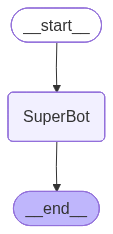

In [4]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [5]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is xyz And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is xyz And I like cricket', additional_kwargs={}, response_metadata={}, id='51a98824-81d0-4ff2-ad00-26413ae6caec'),
  AIMessage(content='Nice to meet you, XYZ. Cricket is a fantastic sport. Are you a fan of a particular team or player? Do you have a favorite format, such as Test matches, ODIs, or T20s?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 45, 'total_tokens': 90, 'completion_time': 0.166486171, 'completion_tokens_details': None, 'prompt_time': 0.001978354, 'prompt_tokens_details': None, 'queue_time': 0.049682806, 'total_time': 0.168464525}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee2f7-d177-7a33-bd1c-8f4073eec0e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 45, 'total_tokens': 

### Streaming
Methods: .stream() and astream()
- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values :** This streams the full state of the graph after each node is called.
- **updates :** This streams updates to the state of the graph after each node is called.

#### Example of Update

In [6]:

# Create a thread
config = {"configurable": {"thread_id": "10"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is xyz And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello XYZ, it's nice to meet you. Cricket is a fantastic sport, with a huge following worldwide. What is it about cricket that you enjoy the most? Is it the thrill of a closely contested match, the skill of the players, or something else? Do you have a favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 45, 'total_tokens': 108, 'completion_time': 0.178695093, 'completion_tokens_details': None, 'prompt_time': 0.0012613, 'prompt_tokens_details': None, 'queue_time': 0.04883654, 'total_time': 0.179956393}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee2f7-d309-7b72-b919-a498820ebcc7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 63, 'total_tokens': 108})]}}


In [7]:

for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="That's great, XYZ. It's excellent that you enjoy both cricket and football. Both sports require a lot of skill, strategy, and physical fitness. Football, in particular, is a highly popular sport globally, with many exciting leagues and tournaments.\n\nSo, do you have a favorite football team or player? Are you more interested in international football, like the World Cup, or do you follow a specific domestic league, such as the English Premier League or La Liga?\n\nAnd, I'm curious, do you think there are any similarities between cricket and football, or do you enjoy them for different reasons?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 121, 'total_tokens': 243, 'completion_time': 0.421748978, 'completion_tokens_details': None, 'prompt_time': 0.00620633, 'prompt_tokens_details': None, 'queue_time': 0.05202829, 'total_time': 0.427955308}, 'model_name': 'llama-3.3-70b-versatile', 'sys

#### Example of Values

In [8]:
# Create a thread
config = {"configurable": {"thread_id": "11"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is xyz And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is xyz And I like cricket', additional_kwargs={}, response_metadata={}, id='735d8194-9a73-4eca-90bb-497357af11d1')]}
{'messages': [HumanMessage(content='Hi,My name is xyz And I like cricket', additional_kwargs={}, response_metadata={}, id='735d8194-9a73-4eca-90bb-497357af11d1'), AIMessage(content='Nice to meet you, XYZ. Cricket is a fantastic sport, and there are many exciting teams and players to follow. Are you a fan of a particular team, such as India, Australia, or England? Or do you have a favorite player like Virat Kohli, Steve Smith, or Babar Azam?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 45, 'total_tokens': 110, 'completion_time': 0.212115764, 'completion_tokens_details': None, 'prompt_time': 0.001733506, 'prompt_tokens_details': None, 'queue_time': 0.052029724, 'total_time': 0.21384927}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'serv

In [9]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is xyz And I like cricket', additional_kwargs={}, response_metadata={}, id='735d8194-9a73-4eca-90bb-497357af11d1'), AIMessage(content='Nice to meet you, XYZ. Cricket is a fantastic sport, and there are many exciting teams and players to follow. Are you a fan of a particular team, such as India, Australia, or England? Or do you have a favorite player like Virat Kohli, Steve Smith, or Babar Azam?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 45, 'total_tokens': 110, 'completion_time': 0.212115764, 'completion_tokens_details': None, 'prompt_time': 0.001733506, 'prompt_tokens_details': None, 'queue_time': 0.052029724, 'total_time': 0.21384927}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee2f7-d6dd-77e0-ab7f-9de1d1c07852-0', tool_calls=[], in

In [10]:
for chunk in graph_builder.stream({'messages':"I also like chess"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is xyz And I like cricket', additional_kwargs={}, response_metadata={}, id='735d8194-9a73-4eca-90bb-497357af11d1'), AIMessage(content='Nice to meet you, XYZ. Cricket is a fantastic sport, and there are many exciting teams and players to follow. Are you a fan of a particular team, such as India, Australia, or England? Or do you have a favorite player like Virat Kohli, Steve Smith, or Babar Azam?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 45, 'total_tokens': 110, 'completion_time': 0.212115764, 'completion_tokens_details': None, 'prompt_time': 0.001733506, 'prompt_tokens_details': None, 'queue_time': 0.052029724, 'total_time': 0.21384927}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee2f7-d6dd-77e0-ab7f-9de1d1c07852-0', tool_calls=[], in

#### Example of async

In [11]:
config = {"configurable": {"thread_id": "15"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is xyz and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is xyz and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ee2f7-ddae-76e2-87fc-62d6baf8619d', 'metadata': {'thread_id': '15', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is xyz and I like to play cricket', additional_kwargs={}, response_metadata={}, id='24da03a6-b8a7-4df9-a5b7-f1be6064f032')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ee2f7-ddb4-7773-8914-6f50bc28da82', 'metadata': {'thread_id': '15', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:d1bcb193-9c22-aa04-3258-fd3b0b4bfce9'}, 'parent_ids': ['019ee2f7-ddae-76e2-87fc-62d6baf8619d']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [